In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

**Question 1**

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

Regular linear models are useful, but they can predict any number, even values that do not make sense, like probabilities below 0 or above 1. Latent variable models keep the linear part, but pass it through an activation function so the output fits the problem better. For example, logistic regression turns the linear score into a probability between 0 and 1.

2. Why are binary and categorical cross entropy effective loss functions for logistic regression?

They work well because logistic regression predicts probabilities. Binary cross entropy measures how well the predicted probability matches a true 0/1 outcome. Categorical cross entropy does the same thing for multiple classes by penalizing the model when it gives low probability to the correct class.

3. True or false: Logistic regression is a linear model.

True (sortof?). Logistic regression is linear in the inside part because it uses a linear combination of the features. However, the final prediction is not linear because it passes that value through the logistic function.

4. True or false: Logistic regression cannot be used for classification.

False. Logistic regression can be used for classification. It predicts a probability, and then we can classify based on a cutoff like 0.5.

5. Does the coefficient represent the change in predicted value for a 1 unit change in the feature?

No, not directly. In logistic regression, the coefficient affects the log-odds, not the probability itself. A positive coefficient means higher probability, and a negative coefficient means lower probability, but the exact probability change depends on where you are on the curve.

6. True or false: Feature engineering is unnecessary because logistic regression is nonlinear.

False. Feature engineering is still important because logistic regression is still linear in the features before the activation function. We may still need interactions, powers, dummy variables, or transformations.

7. True or false: Logistic regression is better than OLS, so we should always use it.

False. Logistic regression is better for binary or categorical outcomes because it gives valid probabilities. But for continuous outcomes, ordinary linear regression is still more appropriate.

**Question 2**

In [ ]:
#1. Load the data and select the relevant columns
df = pd.read_csv("data.csv", delimiter = ";")

df = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]]

print(df.isna().sum())

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


In [8]:
df["dropout"] = df["Target"].map({
    "Dropout": 1,
    "Graduate": 0,
    "Enrolled": 0
})

df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [10]:
from sklearn.linear_model import LogisticRegression

In [11]:
#2. Run a logistic regression of dropout status on Debtor, Tuition fees up to date, Scholarship holder, and Age at enrollment.

y = df["dropout"]

X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

reg = LogisticRegression(penalty = None, max_iter = 1000)
reg = reg.fit(X, y)

coef = pd.DataFrame({
    "Variable": reg.feature_names_in_,
    "Coefficient": reg.coef_[0]
})

coef


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Debtor,0.527137
1,Tuition fees up to date,-2.605617
2,Scholarship holder,-1.242299
3,Age at enrollment,0.049841


Debtor and Age at enrollment have positive coefficients, so they predict a higher dropout probability.

Tuition fees up to date and Scholarship holder have negative coefficients, so they predict a lower dropout probability.

Yes, being up to date on tuition seems to reduce dropout risk because it has a large negative coefficient, -2.61.

In [12]:
#3 Use .predict_proba and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against Age at enrollment, hued by Tuition fees up to date

prob = reg.predict_proba(X)

df["dropout_prob"] = prob[:, 1]

df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,dropout,dropout_prob
0,0,1,0,20,0,Dropout,1,0.254740
1,0,0,0,19,6,Graduate,0,0.814918
2,0,0,0,19,0,Dropout,1,0.814918
3,0,1,0,20,6,Graduate,0,0.254740
4,0,1,0,45,5,Graduate,0,0.543026


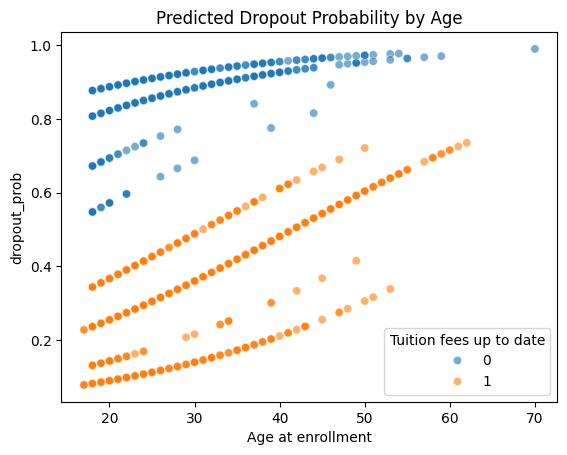

In [13]:
sns.scatterplot(
    data = df,
    x = "Age at enrollment",
    y = "dropout_prob",
    hue = "Tuition fees up to date",
    alpha = 0.6
)

plt.title("Predicted Dropout Probability by Age")
plt.show()

In [14]:
avg_probs = df.groupby("Tuition fees up to date")["dropout_prob"].mean()

print(avg_probs)

effect = avg_probs[0] - avg_probs[1]

print("Average decrease in dropout probability from being up to date:", effect)

Tuition fees up to date
0    0.865533
1    0.247433
Name: dropout_prob, dtype: float64
Average decrease in dropout probability from being up to date: 0.6181006148688428


On average, being up to date on tuition lowers the predicted probability of dropout by about 62%. 
It seems that at ages 20-30 being up to date on tuition seem to reduce dropout probability the most.

In [15]:
#4 Use .predict and compute a confusion matrix for your classifier. What is the accuracy?
y_class = reg.predict(X)

tab = pd.crosstab(y, y_class)

acc = np.trace(tab) / len(y)

print(tab)
print("Accuracy:", acc)

col_0       0    1
dropout           
0        2841  162
1         891  530
Accuracy: 0.7619801084990958


In [17]:
from sklearn.linear_model import LinearRegression

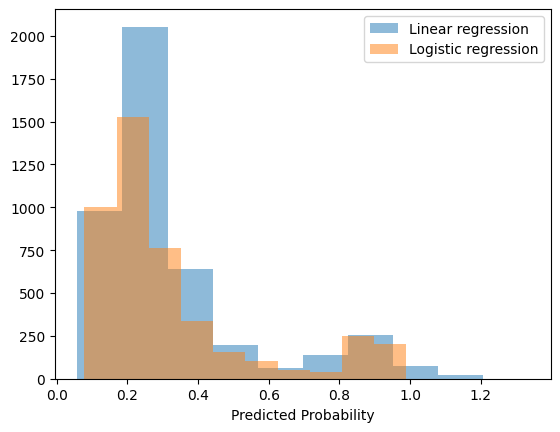

In [20]:
#5 Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

lin_reg = LinearRegression()
lin_reg = lin_reg.fit(X, y)

df["linear_prob"] = lin_reg.predict(X)
df["logistic_prob"] = reg.predict_proba(X)[:, 1]

plt.hist(df["linear_prob"], alpha = 0.5, label = "Linear regression")
plt.hist(df["logistic_prob"], alpha = 0.5, label = "Logistic regression")

plt.xlabel("Predicted Probability")
plt.legend()
plt.show()

Both models show a similar general pattern. However, the logistic regression probabilities stay between 0 and 1, so they make more sense for dropout probability. The linear model can predict values outside the normal probability range, above 1.0 in this case , which is harder to interpret.

Logistic regression is better for this problem because dropout is a binary outcome. The model gives a more reasonable predicted probabilities for classification.

6. The most at risk students are those who are not up to date on tuition, have debt, are not scholarship holders, and are older at enrollment. The biggest factor seems to be tuition status because students not up to date on tuition have much higher predicted dropout probabilities. Some interventions could be more financial aid, tuition payment plans, work-study opportunities, and earlier advising for students with debt or unpaid tuition. Since tuition status seems strongly related to dropout risk, helping students financially could help them stay enrolled.

In [23]:
#7

X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

y_multi = df["Target"]
multi_reg = LogisticRegression(max_iter = 1000)
multi_reg = multi_reg.fit(X_multi, y_multi)

y_multi_class = multi_reg.predict(X_multi)

tab_multi = pd.crosstab(y_multi, y_multi_class)

acc_multi = np.trace(tab_multi) / len(y_multi)

print(tab_multi)
print("Accuracy:", acc_multi)


col_0     Dropout  Graduate
Target                     
Dropout      1054       367
Enrolled      280       514
Graduate      146      2063
Accuracy: 0.35443037974683544


From the confusion matrix, the model only predicts Dropout and Graduate. It does not predict Enrolled at all, because there is no Enrolled column in the prediction results. The accuracy is about 0.35, so the hard classification is not very strong.

In [24]:
probs_multi = pd.DataFrame(
    multi_reg.predict_proba(X_multi),
    columns = multi_reg.classes_
)

probs_multi.head()

,Dropout,Enrolled,Graduate
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104


Using .predict_proba() gives a probability for every class. In the probability table, every row has a probability for Dropout, Enrolled, and Graduate.

Summary: The hard classification does not predict every class, but the predicted probabilities do include every class.

**Question 3**

In [ ]:
#1
df_cirr = pd.read_csv("cirrhosis.csv")

df_cirr = df_cirr[[
    "Bilirubin",
    "Edema",
    "Drug",
    "Stage",
    "Status"
]]

print(df_cirr.isna().sum())

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


In [26]:
df_cirr = df_cirr.dropna(subset = ["Stage"])
df_cirr["Drug"] = df_cirr["Drug"].fillna(df_cirr["Drug"].mode()[0])

print(df_cirr.isna().sum())
df_cirr.head()

Bilirubin    0
Edema        0
Drug         0
Stage        0
Status       0
dtype: int64


,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [ ]:
#2 Run a logistic regression of Status on Edema, Drug, and Bilirubin. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

y_cirr = df_cirr["Status"]

X_cirr = pd.get_dummies(
    df_cirr[["Edema", "Drug", "Bilirubin"]],
    drop_first = True
)

reg_cirr = LogisticRegression(penalty = None, max_iter = 1000)
reg_cirr = reg_cirr.fit(X_cirr, y_cirr)

coef_cirr = pd.DataFrame(reg_cirr.coef_)
coef_cirr = coef_cirr.set_axis(reg_cirr.feature_names_in_, axis = 1)

print(reg_cirr.classes_)
coef_cirr

['C' 'CL' 'D']


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Bilirubin,Edema_S,Edema_Y,Drug_Placebo
0,-0.233001,-0.548933,0.270301,0.029422
1,0.086738,0.051784,-3.393873,-0.019330
2,0.146264,0.497149,3.123572,-0.010093


In [32]:
odds_cirr = np.exp(coef_cirr)

odds_cirr

,Bilirubin,Edema_S,Edema_Y,Drug_Placebo
0,0.792152,0.577566,1.310359,1.029859
1,1.090611,1.053148,0.033578,0.980856
2,1.157501,1.644028,22.727415,0.989958


C = alive
CL = alive
D = dead

The drug does not seem to improve survival probability much. The placebo value is very close to 1, so placebo and D-penicillamine look almost the same in this model.
Higher bilirubin predicts a lower survival rate, because it is associated with higher odds of death. So lower bilirubin predicts better survival.
Survival also gets worse with edema. Patients with no edema have the best survival, patients with controlled edema have lower survival, and patients with severe edema have the lowest survival. Severe edema has the strongest negative effect on survival.

In [33]:
#3Use .predict_proba and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against Bilirubin, hued by Drug. For what values of Bilirubin does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

prob_cirr = pd.DataFrame(
    reg_cirr.predict_proba(X_cirr),
    columns = reg_cirr.classes_
)

prob_cirr.head()

,C,CL,D
0,0.001143,0.000155,0.998702
1,0.721622,0.052758,0.225619
2,0.466430,0.068441,0.465130
3,0.429677,0.071650,0.498673
4,0.536394,0.077924,0.385681


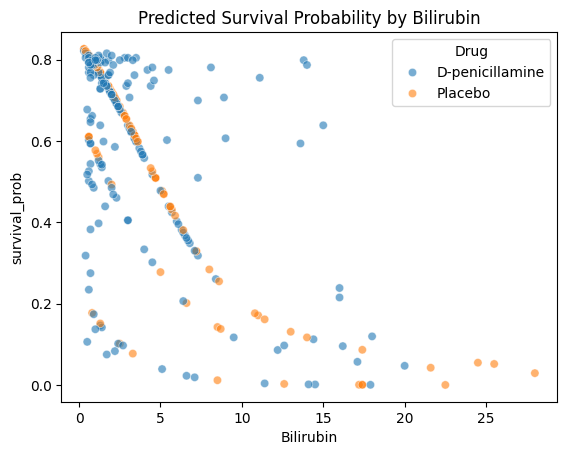

In [35]:
df_cirr["survival_prob"] = 1 - prob_cirr["D"]
sns.scatterplot(
    data = df_cirr,
    x = "Bilirubin",
    y = "survival_prob",
    hue = "Drug",
    alpha = 0.6
)

plt.title("Predicted Survival Probability by Bilirubin")
plt.show()

In [36]:
avg_survival = df_cirr.groupby("Drug")["survival_prob"].mean()

print(avg_survival)

effect = avg_survival["D-penicillamine"] - avg_survival["Placebo"]

print("Average increase in survival probability from taking the drug:", effect)

Drug
D-penicillamine    0.625627
Placebo            0.610486
Name: survival_prob, dtype: float64
Average increase in survival probability from taking the drug: 0.015141357266294064


The drug does not seem to clearly increase survival for every bilirubin value because the drug and placebo points overlap a lot. The drug seems to help a little more at lower to medium bilirubin levels, around 1–8, but the pattern is not super obvious.

On average, the survival probability for patients taking D-penicillamine is 0.626, while placebo is 0.610. So the drug increases survival probability by about 1.5%. This is a REALLY small increase, so I would say the drug does not have a strong effect based on this model.

In [37]:
#4 Use .predict and compute a confusion matrix for your classifier. What is the accuracy?
y_class_cirr = reg_cirr.predict(X_cirr)

tab_cirr = pd.crosstab(y_cirr, y_class_cirr)

acc_cirr = np.trace(tab_cirr) / len(y_cirr)

print(tab_cirr)
print("Accuracy:", acc_cirr)


col_0     C   D
Status         
C       209  21
CL       19   6
D        77  80
Accuracy: 0.5218446601941747


Note that CL is not predicted here

In [39]:
#5 Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.
df_cirr["survived"] = (df_cirr["Status"] != "D").astype(int)

lin_reg_cirr = LinearRegression()
lin_reg_cirr = lin_reg_cirr.fit(X_cirr, df_cirr["survived"])

df_cirr["linear_survival_prob"] = lin_reg_cirr.predict(X_cirr)
df_cirr["logistic_survival_prob"] = 1 - reg_cirr.predict_proba(X_cirr)[:, 2]
reg_cirr.classes_


array(['C', 'CL', 'D'], dtype=object)

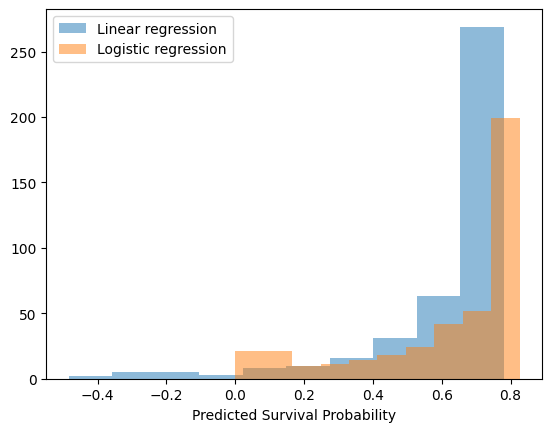

In [40]:
plt.hist(x = df_cirr["linear_survival_prob"], alpha = 0.5, label = "Linear regression")
plt.hist(x = df_cirr["logistic_survival_prob"], alpha = 0.5, label = "Logistic regression")
plt.xlabel("Predicted Survival Probability")
plt.legend()
plt.show()


The two models have a similar general shape, but the linear regression model has a larger range of predicted survival probabilities and even goes below 0, which does not make sense for a probability. Logistic regression keeps the predicted survival probabilities between 0 and 1. Since we are looking at survival probabilities, the logistic model is easier to interpret and more appropriate for this problem.

In [ ]:
#6 Run a logistic regression of Stage on Edema and Bilirubin. Use .predict to make a hard classification, and compute a confusion matrix. Describe your results. Use .predict_proba to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

X_stage = pd.get_dummies(
    df_cirr[["Edema", "Bilirubin"]],
    drop_first = True
)

y_stage = df_cirr["Stage"]

stage_reg = LogisticRegression(max_iter = 1000)
stage_reg = stage_reg.fit(X_stage, y_stage)

#. predict
y_stage_class = stage_reg.predict(X_stage)

tab_stage = pd.crosstab(y_stage, y_stage_class)

acc_stage = np.trace(tab_stage) / len(y_stage)

print(tab_stage)
print("Accuracy:", acc_stage)

# .predict_proba
stage_probs = pd.DataFrame(
    stage_reg.predict_proba(X_stage),
    columns = stage_reg.classes_
)

stage_probs.head()


col_0  3.0  4.0
Stage          
1.0     20    1
2.0     82   10
3.0    130   25
4.0     93   51
Accuracy: 0.07281553398058252


,1.0,2.0,3.0,4.0
0,0.000469,0.051112,0.137333,0.811086
1,0.068674,0.255047,0.397582,0.278697
2,0.039844,0.139561,0.340088,0.480506
3,0.035217,0.137519,0.338843,0.488421
4,0.035048,0.243195,0.404020,0.317737


For the confiusion matrix (the hard classifier), the model only predicted stages 3 and 4 because they were the one of the classes with the highest predicted proability each time. Despite this, the model's accruacy is 7.3%, which is quite low. so our model may not be performing well.

Our probability table, on the other hand, shows the probability for every stage. Thus, the predicted probability includes every class but hard classification only chooses those with the highest probability.

**Question 4**

1. For the linear model, the derivative with respect to the \(k\)-th feature is:

$$
\frac{\partial \hat{y}}{\partial x_k} = b_k
$$

For a 1 unit increase in x_k\, the prediction changes by b_k. 


2. For the logistic model,the derivative with respect to the \(k\)-th feature is:

$$
\frac{\partial \hat{p}}{\partial x_k} = b_k\hat{p}(1-\hat{p})
$$

As \(x\) changes, \(\hat{p}\) changes too, so the effect changes. Similar in the fact that it will still depend on \(b_k\), different in that it will depend on predicted probability \(\hat{p}\) too . 

When \(\hat{p}\) is close to 0 or 1, the effect is small. When \(\hat{p}\) is around 0.5, the effect is largest because 0.5(1-0.5) = 0.25
At  \(\hat{p} = 0.5\), the coefficient divided by 4 is a rough estimate of how a 1 unit change in \(x_k\) affects the predicted probability.


3. A 1 unit increase in \(x_k\) changes the log odds by \(b_k\). 